In [1]:
path = "/content/drive/MyDrive/Data_IRL/data/train"

In [2]:
import os
import numpy as np
import cv2
import random
from torch.utils.data import Dataset

def load_real_data(data_dir, num_samples=None, split_ratio=0.8):
    """
    Load real data from the specified directory and split it into training and testing sets.
    Args:
        data_dir: Path to the directory containing images and annotations.
        num_samples: Number of samples to load (if None, load all).
        split_ratio: Proportion of the dataset to use for training (default 0.8 for 80%).
    Returns:
        train_data: Dictionary of training data.
        test_data: Dictionary of testing data.
    """
    data_dict = {}

    # Get list of image files
    image_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.jpg')])
    if num_samples is not None:
        image_files = image_files[:num_samples]

    for img_file in image_files:
        # Load image
        img_path = os.path.join(data_dir, img_file)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB
        h, w, _ = image.shape

        # Load corresponding annotations
        txt_file = img_file.replace('.jpg', '.txt')
        txt_path = os.path.join(data_dir, txt_file)
        if not os.path.exists(txt_path):
            continue  # Skip if no annotation file

        with open(txt_path, 'r') as f:
            lines = f.readlines()

        # Parse bounding boxes and class IDs
        img_bboxes = []
        for line in lines:
            class_id, x_center, y_center, width, height = map(float, line.strip().split())

            # Convert normalized [x_center, y_center, width, height] to [x_min, y_min, x_max, y_max]
            x_min = (x_center - width / 2) * w
            y_min = (y_center - height / 2) * h
            x_max = (x_center + width / 2) * w
            y_max = (y_center + height / 2) * h

            img_bboxes.append({
                "class_id": int(class_id),
                "bbox": [x_min, y_min, x_max, y_max]
            })

        # If no bounding boxes, skip this image
        if len(img_bboxes) == 0:
            continue

        # Store the image and bounding boxes in the dictionary
        data_dict[img_file] = {
            "image": image,
            "bboxes": img_bboxes
        }

    # Shuffle the data for randomness
    all_images = list(data_dict.items())
    random.shuffle(all_images)

    # Calculate split index
    split_idx = int(len(all_images) * split_ratio)

    # Split into training and testing data
    train_data = dict(all_images[:split_idx])
    test_data = dict(all_images[split_idx:])

    return train_data, test_data


In [3]:
data_folder = path
train_data, test_data = load_real_data(data_folder, num_samples=30, split_ratio=0.8)

In [4]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.preprocessing import StandardScaler

In [15]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision import models

# Load pretrained ResNet model and remove classification head
resnet = models.resnet50(pretrained=True)
resnet = nn.Sequential(*list(resnet.children())[:-1])  # Remove last layer (FC layer)
resnet.eval()  # Set to evaluation mode

# Define image transformation for ResNet
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),  # ResNet input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features_resnet(image, bbox):
    """Extract features from a bbox region using ResNet-50."""
    x_min, y_min, x_max, y_max = map(int, bbox)
    region = image[y_min:y_max, x_min:x_max]

    if region.size == 0:
        return torch.zeros(2048).numpy()  # ResNet-50 output feature size

    # Convert image region to tensor
    region = transform(region).unsqueeze(0)  # Add batch dimension

    # Get ResNet feature embedding
    with torch.no_grad():
        features = resnet(region).squeeze()  # Shape: (2048,)

    return features.numpy()  # Convert to NumPy array


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 154MB/s]


In [18]:
def generate_candidates(image, grid_step=50):
    """Generate grid-based candidate bboxes."""
    h, w = image.shape[:2]
    candidates = []
    for x in range(0, w - grid_step, grid_step):
        for y in range(0, h - grid_step, grid_step):
            candidates.append([x, y, x + grid_step, y + grid_step])
    return candidates

In [20]:
# Collect feature differences and constraints
feature_diffs = []
for img_id, img_data in train_data.items():
    image = img_data['image']
    expert_bboxes = [bbox['bbox'] for bbox in img_data['bboxes']]
    candidates = generate_candidates(image)

    for expert_bbox in expert_bboxes:
        # Extract expert features
        expert_feat = extract_features_resnet(image, expert_bbox)

        # Compare with non-expert candidates
        for candidate in candidates:
            if candidate not in expert_bboxes:  # Simplified check; use IoU in practice
                candidate_feat = extract_features_resnet(image, candidate)
                feature_diff = expert_feat - candidate_feat
                feature_diffs.append(feature_diff)

In [25]:
pip install ecos

In [29]:
train_data.get("000000022.jpg")

{'image': array([[[ 77,  85,  98],
         [ 77,  85,  98],
         [ 78,  86,  99],
         ...,
         [161, 156, 150],
         [174, 169, 163],
         [172, 167, 161]],
 
        [[ 76,  84,  97],
         [ 75,  83,  96],
         [ 75,  83,  96],
         ...,
         [166, 161, 155],
         [162, 157, 151],
         [168, 163, 157]],
 
        [[ 79,  87, 100],
         [ 76,  84,  97],
         [ 75,  83,  96],
         ...,
         [161, 156, 150],
         [167, 162, 156],
         [166, 161, 155]],
 
        ...,
 
        [[ 99, 103, 102],
         [ 98, 102, 101],
         [ 99, 103, 102],
         ...,
         [ 83,  90,  82],
         [ 71,  78,  70],
         [108, 116, 105]],
 
        [[101, 105, 104],
         [102, 106, 105],
         [101, 105, 104],
         ...,
         [ 63,  70,  62],
         [ 55,  62,  54],
         [ 35,  42,  34]],
 
        [[103, 107, 106],
         [105, 109, 108],
         [104, 108, 107],
         ...,
         [103, 110,

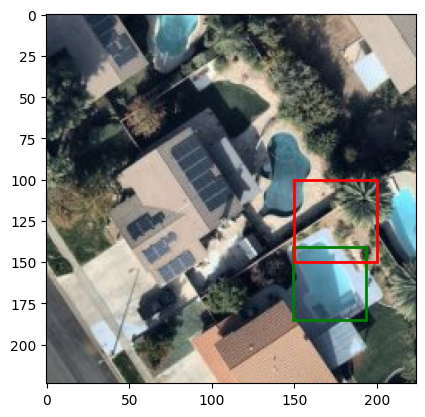

In [30]:
X = np.array(feature_diffs)
n_samples, n_features = X.shape
C = 1.0  # Regularization parameter

# Define and solve the convex optimization problem
theta = cp.Variable(n_features)
slack = cp.Variable(n_samples)
objective = cp.Minimize(0.5 * cp.sum_squares(theta) + C * cp.sum(slack))
constraints = [X @ theta >= 1 - slack, slack >= 0]
prob = cp.Problem(objective, constraints)
prob.solve(solver=cp.SCS)

# Predict function using ResNet features
def predict_bbox(image, theta, grid_step=50):
    candidates = generate_candidates(image, grid_step)
    scores = []
    for bbox in candidates:
        feat = extract_features_resnet(image, bbox)
        scores.append(theta.value @ feat)
    best_idx = np.argmax(scores)
    return candidates[best_idx]

# Visualization for one image
img_id = '000000022.jpg'
img_data = train_data[img_id]
image = img_data['image']
expert_bbox = img_data['bboxes'][0]['bbox']
predicted_bbox = predict_bbox(image, theta)

# Create figure and axes
fig, ax = plt.subplots(1)
ax.imshow(image)

# Draw expert bbox (green)
rect = patches.Rectangle((expert_bbox[0], expert_bbox[1]),
                         expert_bbox[2]-expert_bbox[0],
                         expert_bbox[3]-expert_bbox[1],
                         linewidth=2, edgecolor='g', facecolor='none')
ax.add_patch(rect)

# Draw predicted bbox (red)
rect = patches.Rectangle((predicted_bbox[0], predicted_bbox[1]),
                         predicted_bbox[2]-predicted_bbox[0],
                         predicted_bbox[3]-predicted_bbox[1],
                         linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)

plt.show()

In [31]:
# Function to compute IoU
def compute_iou(box1, box2):
    """Compute Intersection over Union (IoU) between two bounding boxes."""
    x1, y1, x2, y2 = box1
    x1_p, y1_p, x2_p, y2_p = box2

    # Compute intersection
    x_left = max(x1, x1_p)
    y_top = max(y1, y1_p)
    x_right = min(x2, x2_p)
    y_bottom = min(y2, y2_p)

    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No overlap

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x2_p - x1_p) * (y2_p - y1_p)

    union_area = area1 + area2 - intersection_area
    return intersection_area / union_area

# Function to compute Dice Score
def compute_dice(box1, box2):
    """Compute Dice Score between two bounding boxes."""
    x1, y1, x2, y2 = box1
    x1_p, y1_p, x2_p, y2_p = box2

    # Compute intersection
    x_left = max(x1, x1_p)
    y_top = max(y1, y1_p)
    x_right = min(x2, x2_p)
    y_bottom = min(y2, y2_p)

    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No overlap

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    area1 = (x2 - x1) * (y2 - y1)
    area2 = (x2_p - x1_p) * (y2_p - y1_p)

    return (2 * intersection_area) / (area1 + area2)

In [32]:
# Compute IoU and Dice Score
iou_score = compute_iou(expert_bbox, predicted_bbox)
dice_score = compute_dice(expert_bbox, predicted_bbox)

# Display IoU and Dice Score
print(f"IoU: {iou_score:.4f}")
print(f"Dice Score: {dice_score:.4f}")

IoU: 0.0978
Dice Score: 0.1781
